In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
import rioxarray
import numpy as np
from rasterio.enums import Resampling

In [20]:
current_dir = Path.cwd()
data_dir = current_dir.parent / "data"

copernicus_data = []
for file in (data_dir / "copernicus").glob("*.tif"):
    with rioxarray.open_rasterio(file) as data:
        copernicus_data.append(data.squeeze().drop_vars("band").load())

dataforsyningen_data = []
for file in (data_dir / "dataforsyningen").glob("*.tif"):
    with rioxarray.open_rasterio(file) as data:
        dataforsyningen_data.append(data.squeeze().drop_vars("band").load())

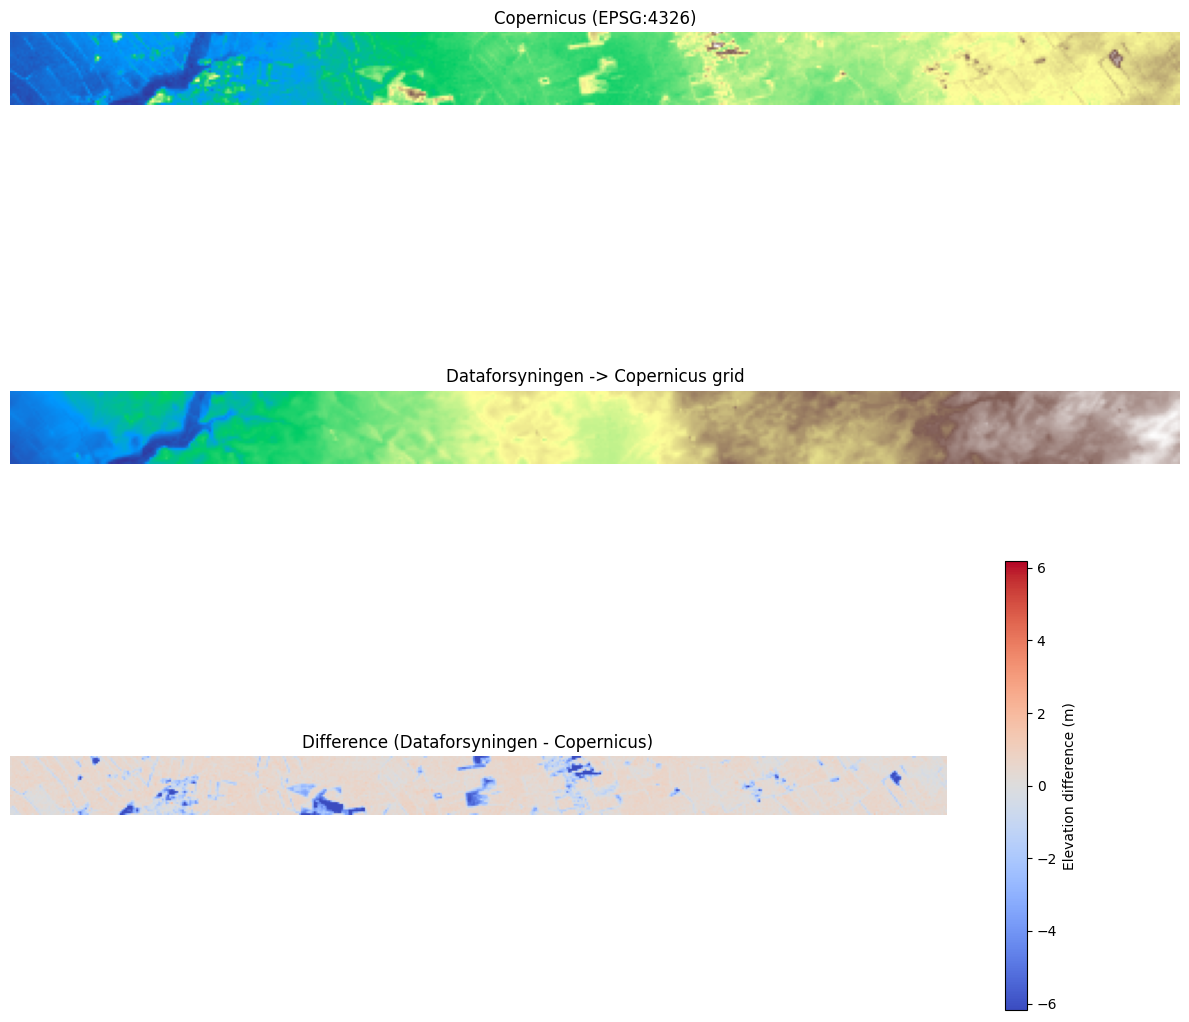

In [ ]:
copernicus_first = copernicus_data[0]
dataforsyningen_first = dataforsyningen_data[0]

# Ensure CRS metadata exists
if copernicus_first.rio.crs is None:
    copernicus_first = copernicus_first.rio.write_crs("EPSG:4326")
if dataforsyningen_first.rio.crs is None:
    dataforsyningen_first = dataforsyningen_first.rio.write_crs("EPSG:25832")

# Reproject Dataforsyningen onto the exact Copernicus grid
dataforsyningen_on_copernicus = dataforsyningen_first.rio.reproject_match(
    copernicus_first,
    resampling=Resampling.bilinear,
    nodata=np.nan,
    dtype="float32",
)

# Compare only finite pixels
copernicus_values = copernicus_first.values.astype("float32")
aligned_values = dataforsyningen_on_copernicus.values.astype("float32")
valid = np.isfinite(copernicus_values) & np.isfinite(aligned_values)
difference = aligned_values - copernicus_values

difference_limit = np.nanpercentile(np.abs(difference[valid]), 99)

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

elevation_min = np.nanpercentile(copernicus_values[valid], 2)
elevation_max = np.nanpercentile(copernicus_values[valid], 98)

axes[0].imshow(copernicus_values, cmap="terrain", vmin=elevation_min, vmax=elevation_max)
axes[0].set_title("Copernicus (EPSG:4326)")

axes[1].imshow(aligned_values, cmap="terrain", vmin=elevation_min, vmax=elevation_max)
axes[1].set_title("Dataforsyningen -> Copernicus grid")

difference_image = axes[2].imshow(difference, cmap="coolwarm", vmin=-difference_limit, vmax=difference_limit)
axes[2].set_title("Difference (Dataforsyningen - Copernicus)")
fig.colorbar(difference_image, ax=axes[2], label="Elevation difference (m)")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()